# 11 · Uncertainty - deep dive (20 figures)

Notebooks 07 and 09 established the negative baseline: Boltz-2 **structural** confidence is ~chance for activity and does not improve enrichment. That is not the end of the question. With the full run now in hand we have three genuinely different uncertainty sources to interrogate:

1. **Within-model** - the two affinity heads' disagreement (No-FT and head-FT).
2. **Epistemic** - the spread of the score across the 5 head-FT seeds (same data, different init).
3. **Confidence / entropy / novelty** - structural confidence, predictive entropy, distance to the training set.

The question this notebook actually tries to answer: *is any uncertainty measure actionable* - does it flag the model's errors, does abstaining on it improve early enrichment, does fine-tuning reduce it where it matters, and can it be combined with the score to rank better? We report honestly, including where the answer is no.

In [1]:

import glob, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score
BLK="#000000"; C0="#2a78d6"; C1="#eb6834"; C2="#1baf7a"; C3="#9467bd"; NEU="#666666"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT="/global/scratch/users/sergiomar10/boltzaff"; R=ROOT+"/results/runs/588689"
BASE_RATE=None
def load_arm(d):
    fs=sorted(glob.glob(d+"/chunk_*.csv"))
    if not fs: return None
    f=pd.concat([pd.read_csv(p) for p in fs],ignore_index=True)
    f["sample_id"]=f.sample_id.astype(str); f=f.drop_duplicates("sample_id")
    return f
# --- No-FT base (two heads) ---
bs=load_arm(R+"/headft_affcache/base/scores").set_index("sample_id")
# --- head-FT arms: all 15 (5 seeds x {40,100,300}) ---
FT={}
for N in (40,100,300):
    for s in range(5):
        a=load_arm(R+f"/headft_affcache/lightning_top{N}_seed{s}/scores")
        if a is not None: FT[(N,s)]=a.set_index("sample_id")
print("loaded base + %d head-FT arms"%len(FT))
# --- labels + confidence + smiles ---
LB=pd.read_csv(R+"/ft_inputs_full/ml_table.csv",usecols=["complex_id","is_binder"],dtype={"complex_id":str}).set_index("complex_id").is_binder.astype(int)
qc=pd.read_csv(R+"/qc.csv"); qc["sid"]="588689_"+qc.CID.astype(str); qc=qc.set_index("sid")
res=pd.read_csv(ROOT+"/data/588689_results.csv"); res["sid"]="588689_"+res.CID.astype(str); res=res.set_index("sid")
# --- master frame on the common eval set ---
ids=bs.index
m=pd.DataFrame(index=ids)
m["label"]=LB.reindex(ids).fillna(0).astype(int)
m["score0"]=bs.affinity_probability_binary               # No-FT score
m["disagree0"]=(bs.affinity_probability_binary1-bs.affinity_probability_binary2).abs()
p0=m.score0.clip(1e-6,1-1e-6); m["entropy0"]=-(p0*np.log2(p0)+(1-p0)*np.log2(1-p0))
# head-FT top300: cross-seed matrix + mean + two-head disagreement
S300=pd.DataFrame({s:FT[(300,s)].affinity_probability_binary.reindex(ids) for s in range(5)})
m["ft300_mean"]=S300.mean(axis=1); m["cross_seed_sd"]=S300.std(axis=1,ddof=1)
m["ft300_disagree"]=np.mean([ (FT[(300,s)].affinity_probability_binary1.reindex(ids)-FT[(300,s)].affinity_probability_binary2.reindex(ids)).abs() for s in range(5)],axis=0)
for c in ["confidence","ligand_iptm","complex_plddt"]: m[c]=qc[c].reindex(ids)
m["smiles"]=res["neut-smiles"].reindex(ids)
BASE_RATE=m.label.mean()
print(f"eval={len(m):,}  actives={int(m.label.sum())} ({100*BASE_RATE:.2f}%)")
UNC={"two-head (No-FT)":"disagree0","two-head (FT N=300)":"ft300_disagree","cross-seed SD (FT N=300)":"cross_seed_sd",
     "predictive entropy":"entropy0","1 - confidence":None,"1 - ligand ipTM":None}
m["u_conf"]=1-m["confidence"]; m["u_ligiptm"]=1-m["ligand_iptm"]
UNC["1 - confidence"]="u_conf"; UNC["1 - ligand ipTM"]="u_ligiptm"
def ef1(score,label):
    k=max(1,int(0.01*len(score))); idx=np.argsort(-score)[:k]
    return label[idx].mean()/max(label.mean(),1e-9)


loaded base + 15 head-FT arms


eval=49,985  actives=486 (0.97%)


## Part I - the uncertainty measures and how they relate
### Fig 1. Distributions of the three core uncertainty measures
Different shapes: two-head disagreement and cross-seed SD are right-skewed (most compounds certain, a tail of doubt); confidence-based uncertainty is broader.

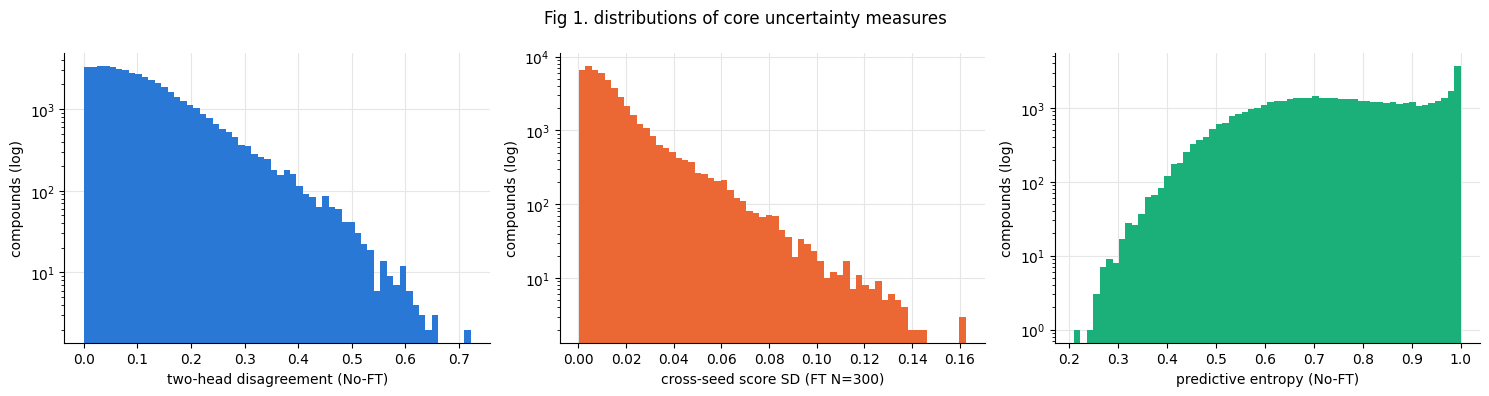

In [2]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(lab,col,c) in zip(axes,[("two-head disagreement (No-FT)","disagree0",C0),("cross-seed score SD (FT N=300)","cross_seed_sd",C1),("predictive entropy (No-FT)","entropy0",C2)]):
    v=m[col].dropna(); ax.hist(v,bins=60,color=c); ax.set_yscale("log"); ax.set_xlabel(lab); ax.set_ylabel("compounds (log)")
fig.suptitle("Fig 1. distributions of core uncertainty measures",fontsize=12); plt.tight_layout(); plt.show()

### Fig 2. Do the uncertainty measures agree?
Spearman correlations among all six measures. If they were redundant they would correlate strongly; if they capture different things (within-model vs epistemic vs structural) they will not.

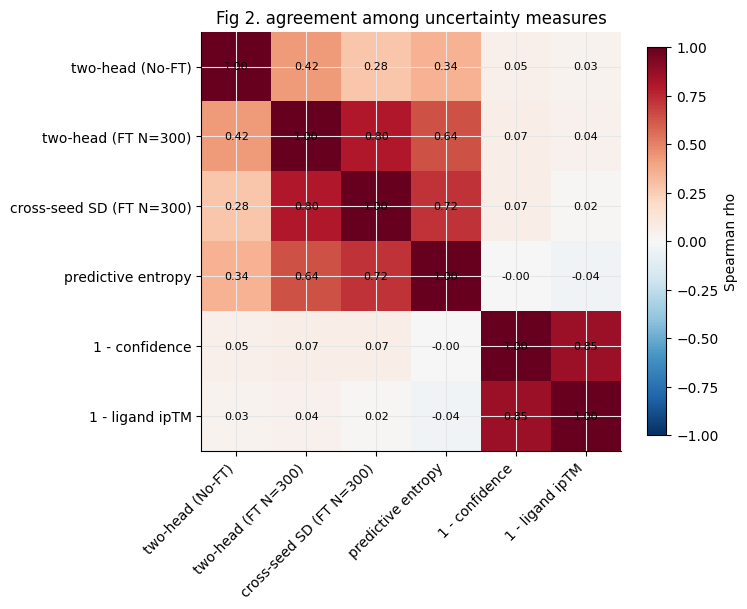

In [3]:
cols=list(UNC.values()); labs=list(UNC.keys())
cc=m[cols].corr(method="spearman")
fig,ax=plt.subplots(figsize=(7.5,6.5)); im=ax.imshow(cc.values,vmin=-1,vmax=1,cmap="RdBu_r")
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs,rotation=45,ha="right"); ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs)
for i in range(len(labs)):
    for j in range(len(labs)): ax.text(j,i,f"{cc.values[i,j]:.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,shrink=0.8,label="Spearman rho"); ax.set_title("Fig 2. agreement among uncertainty measures"); plt.tight_layout(); plt.show()

### Fig 3. Within-model vs epistemic uncertainty
Two-head disagreement (one model, two heads) vs cross-seed SD (five independently fine-tuned models). Weak correlation = they are complementary signals, not the same doubt.

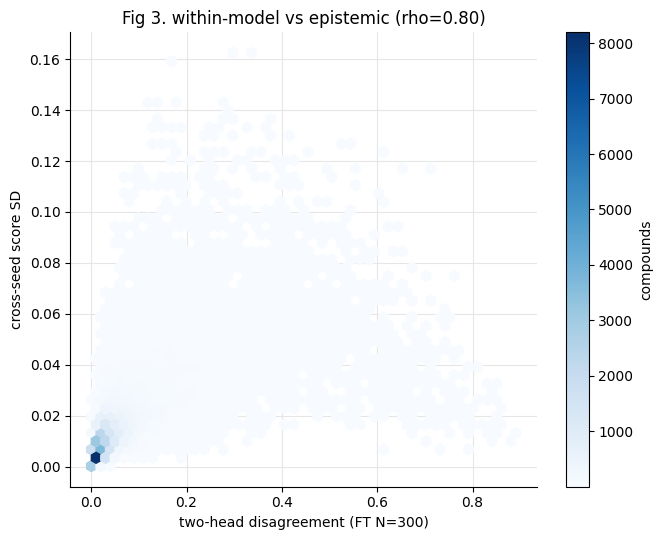

In [4]:
d=m[["ft300_disagree","cross_seed_sd"]].dropna()
fig,ax=plt.subplots(figsize=(6.8,5.5)); hb=ax.hexbin(d.ft300_disagree,d.cross_seed_sd,gridsize=45,cmap="Blues",mincnt=1)
ax.set_xlabel("two-head disagreement (FT N=300)"); ax.set_ylabel("cross-seed score SD")
ax.set_title(f"Fig 3. within-model vs epistemic (rho={d.corr(method='spearman').iloc[0,1]:.2f})"); fig.colorbar(hb,ax=ax,label="compounds"); plt.tight_layout(); plt.show()

### Fig 4. Where each uncertainty lives along the score
Mean uncertainty per predicted-score decile. Within-model/entropy peak mid-score (decision boundary); if epistemic uncertainty peaks elsewhere it is telling us something the score alone does not.

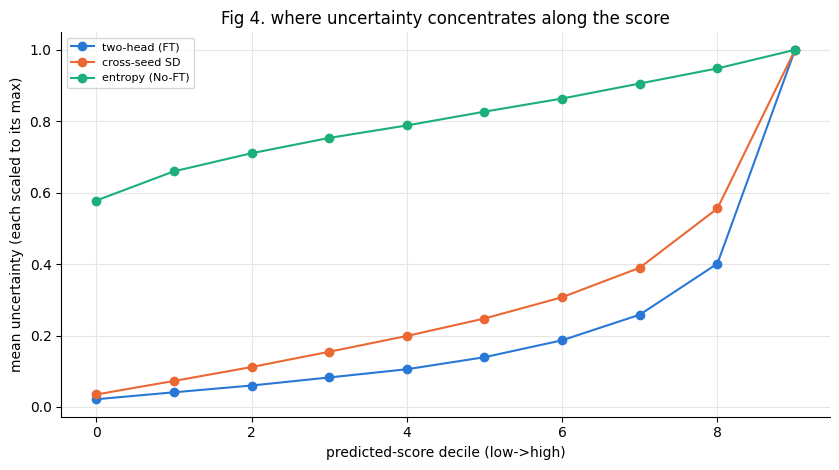

In [5]:
fig,ax=plt.subplots(figsize=(8.5,4.8))
m["sdec"]=pd.qcut(m.ft300_mean,10,labels=False,duplicates="drop")
for lab,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1),("entropy (No-FT)","entropy0",C2)]:
    g=m.groupby("sdec")[col].mean(); ax.plot(g.index,g.values/g.max(),marker="o",color=c,label=lab)
ax.set_xlabel("predicted-score decile (low->high)"); ax.set_ylabel("mean uncertainty (each scaled to its max)")
ax.set_title("Fig 4. where uncertainty concentrates along the score"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part II - does uncertainty predict the model's errors?
### Fig 5. Recovered vs missed actives
The actives that matter: those the model ranks into the top 1% (recovered) vs those it misses. If uncertainty were useful, missed actives would carry higher uncertainty.

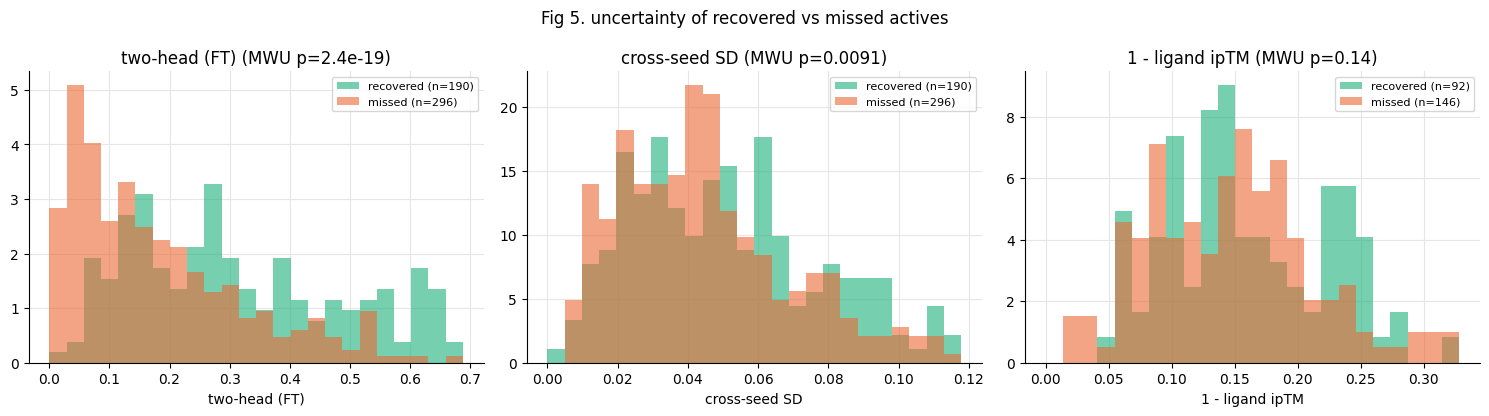

In [6]:
sc=m.ft300_mean.values; k=max(1,int(0.01*len(m))); topset=set(np.argsort(-sc)[:k])
act=m[m.label==1].copy(); pos=np.where(m.label.values==1)[0]
act["recovered"]=[ (i in topset) for i in pos]
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
for ax,(lab,col) in zip(axes,[("two-head (FT)","ft300_disagree"),("cross-seed SD","cross_seed_sd"),("1 - ligand ipTM","u_ligiptm")]):
    r=act[act.recovered][col].dropna(); mi=act[~act.recovered][col].dropna()
    bins=np.linspace(0,np.nanpercentile(act[col],98),25)
    ax.hist(r,bins=bins,density=True,color=C2,alpha=0.6,label=f"recovered (n={len(r)})")
    ax.hist(mi,bins=bins,density=True,color=C1,alpha=0.6,label=f"missed (n={len(mi)})")
    try: pv=stats.mannwhitneyu(r,mi).pvalue
    except Exception: pv=float("nan")
    ax.set_xlabel(lab); ax.set_title(f"{lab} (MWU p={pv:.2g})"); ax.legend(fontsize=8)
fig.suptitle("Fig 5. uncertainty of recovered vs missed actives",fontsize=12); plt.tight_layout(); plt.show()

### Fig 6. Error rate by uncertainty bin
Bin compounds by each uncertainty measure; plot the false-positive rate among the top-scored in each bin. A useful measure would show rising error with rising uncertainty.

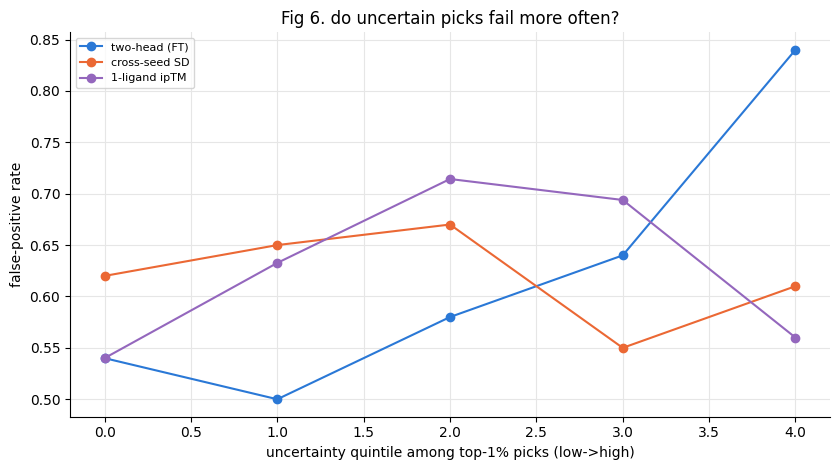

In [7]:
top=m[m.ft300_mean>m.ft300_mean.quantile(0.99)].copy()  # the compounds we would actually pick
fig,ax=plt.subplots(figsize=(8.5,4.8))
for lab,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1),("1-ligand ipTM","u_ligiptm",C3)]:
    t=top.dropna(subset=[col]).copy();
    if len(t)<50: continue
    t["q"]=pd.qcut(t[col],5,labels=False,duplicates="drop")
    g=1-t.groupby("q").label.mean()  # false-positive rate among picks
    ax.plot(g.index,g.values,marker="o",color=c,label=lab)
ax.set_xlabel("uncertainty quintile among top-1% picks (low->high)"); ax.set_ylabel("false-positive rate")
ax.set_title("Fig 6. do uncertain picks fail more often?"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fig 7. AUROC of each uncertainty for flagging a misranked active
Define a 'model error' as an active scored below the median (should be high, is low). How well does each uncertainty predict that error? 0.5 = useless.

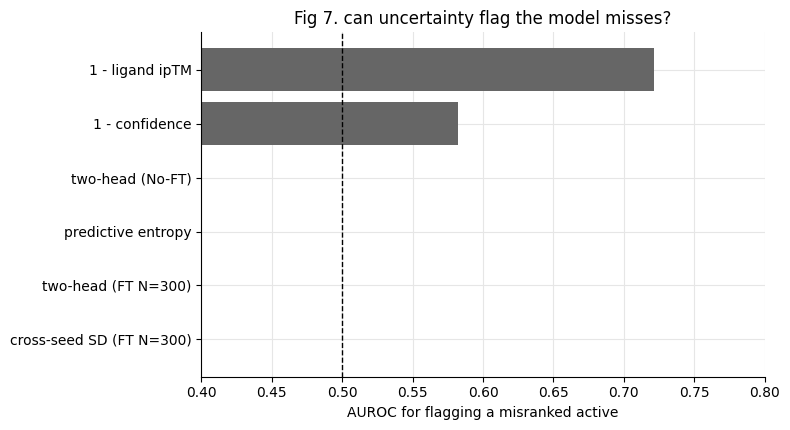

,measure,AUROC
2,cross-seed SD (FT N=300),0.021
1,two-head (FT N=300),0.039
3,predictive entropy,0.141
0,two-head (No-FT),0.303
4,1 - confidence,0.582
5,1 - ligand ipTM,0.721


In [8]:
actm=m[m.label==1].copy(); actm["err"]=(actm.ft300_mean<m.ft300_mean.median()).astype(int)
rows=[]
for lab,col in UNC.items():
    d=actm[[col,"err"]].dropna();
    if d.err.nunique()<2: continue
    au=roc_auc_score(d.err,d[col]); rows.append((lab,au))
au=pd.DataFrame(rows,columns=["measure","AUROC"]).sort_values("AUROC")
fig,ax=plt.subplots(figsize=(8,4.4)); ax.barh(au.measure,au.AUROC,color=NEU); ax.axvline(0.5,ls="--",color=BLK,lw=1)
ax.set_xlim(0.4,0.8); ax.set_xlabel("AUROC for flagging a misranked active"); ax.set_title("Fig 7. can uncertainty flag the model misses?"); plt.tight_layout(); plt.show(); display(au.round(3))

### Fig 8. Calibration of the No-FT vs head-FT score
Reliability curves. Fine-tuning should, ideally, both rank better and be better calibrated. Overlaid with the active base rate.

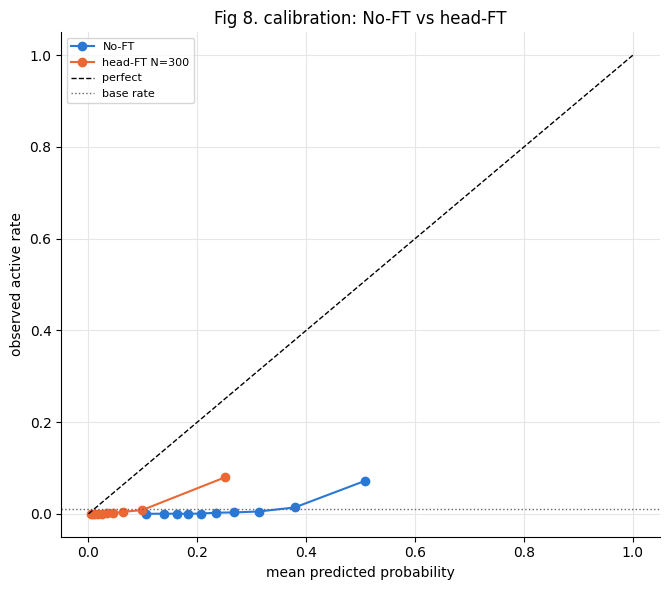

In [9]:
fig,ax=plt.subplots(figsize=(6.8,6))
for lab,col,c in [("No-FT","score0",C0),("head-FT N=300","ft300_mean",C1)]:
    d=m[[col,"label"]].dropna().copy(); d["b"]=pd.qcut(d[col],10,duplicates="drop")
    g=d.groupby("b",observed=True).agg(p=(col,"mean"),o=("label","mean")); ax.plot(g.p,g.o,marker="o",color=c,label=lab)
ax.plot([0,1],[0,1],ls="--",color=BLK,lw=1,label="perfect"); ax.axhline(BASE_RATE,ls=":",color=NEU,lw=1,label="base rate")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed active rate"); ax.set_title("Fig 8. calibration: No-FT vs head-FT"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part III - selective prediction: does abstaining help enrichment?
### Fig 9. Risk-coverage - EF@1% among the most-confident kept fraction
For each measure, keep the most-confident (lowest-uncertainty) X% of the library, re-rank by the score, and measure EF@1% among kept. If a measure is useful, EF rises as we tighten coverage.

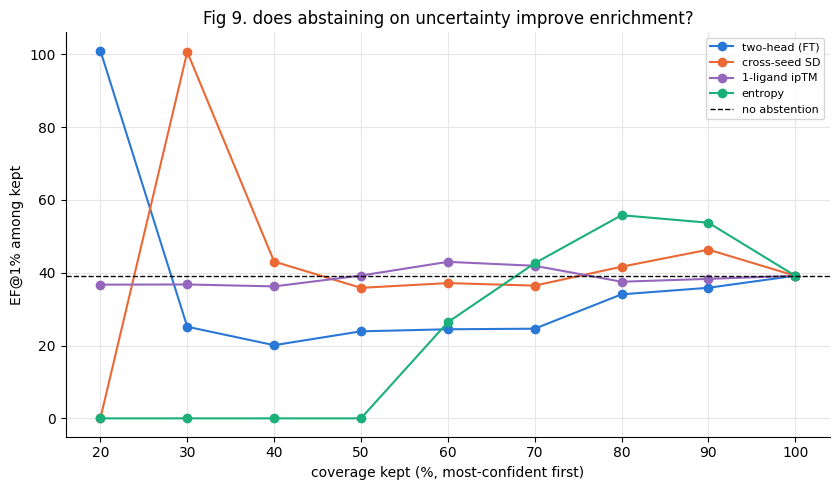

In [10]:
covs=np.linspace(0.2,1.0,9); sc=m.ft300_mean.values; lab_=m.label.values
fig,ax=plt.subplots(figsize=(8.5,5))
for name,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1),("1-ligand ipTM","u_ligiptm",C3),("entropy","entropy0",C2)]:
    u=m[col].values; ys=[]
    for cv in covs:
        keep=np.argsort(u)[:int(cv*len(u))]  # lowest uncertainty
        ys.append(ef1(sc[keep],lab_[keep]))
    ax.plot(100*covs,ys,marker="o",color=c,label=name)
ax.axhline(ef1(sc,lab_),ls="--",color=BLK,lw=1,label="no abstention")
ax.set_xlabel("coverage kept (%, most-confident first)"); ax.set_ylabel("EF@1% among kept")
ax.set_title("Fig 9. does abstaining on uncertainty improve enrichment?"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fig 10. AP vs coverage
Same abstention experiment measured by average precision (whole-ranking quality), not just the top 1%.

/clusterfs/nilah/sergio/miniconda3/envs/boltzba/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


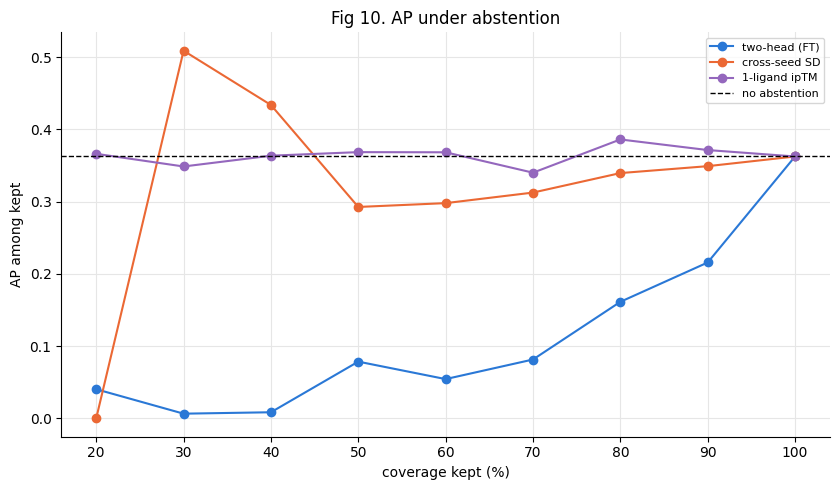

In [11]:
fig,ax=plt.subplots(figsize=(8.5,5))
for name,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1),("1-ligand ipTM","u_ligiptm",C3)]:
    u=m[col].values; ys=[]
    for cv in covs:
        keep=np.argsort(u)[:int(cv*len(u))]
        ys.append(average_precision_score(lab_[keep],sc[keep]))
    ax.plot(100*covs,ys,marker="o",color=c,label=name)
ax.axhline(average_precision_score(lab_,sc),ls="--",color=BLK,lw=1,label="no abstention")
ax.set_xlabel("coverage kept (%)"); ax.set_ylabel("AP among kept"); ax.set_title("Fig 10. AP under abstention"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fig 11. Do we keep the actives when we abstain?
Abstention only helps if it drops decoys, not actives. Fraction of all actives retained vs coverage, for uncertainty-guided vs random abstention.

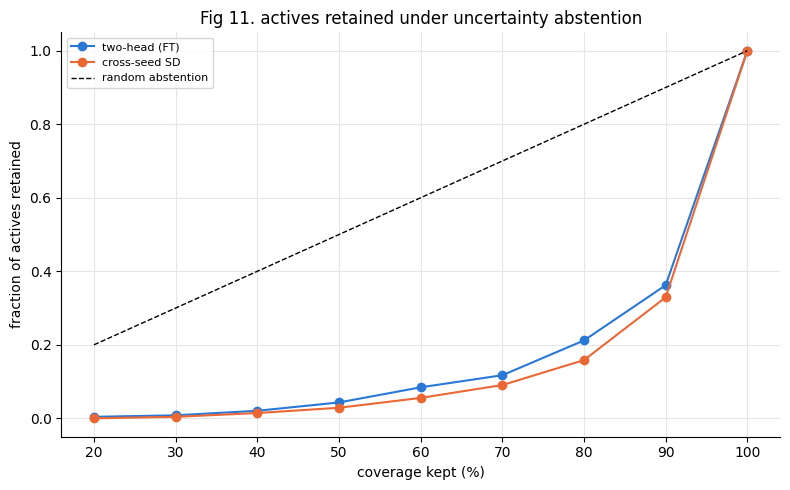

In [12]:
fig,ax=plt.subplots(figsize=(8,5)); nact=int(lab_.sum())
for name,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1)]:
    u=m[col].values; ys=[np.sum(lab_[np.argsort(u)[:int(cv*len(u))]])/nact for cv in covs]; ax.plot(100*covs,ys,marker="o",color=c,label=name)
ax.plot(100*covs,covs,ls="--",color=BLK,lw=1,label="random abstention"); ax.set_xlabel("coverage kept (%)"); ax.set_ylabel("fraction of actives retained")
ax.set_title("Fig 11. actives retained under uncertainty abstention"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fig 12. Uncertainty-guided vs random abstention (lift)
The head-to-head: EF@1% from abstaining by uncertainty minus EF@1% from removing the same fraction at random (averaged over draws). Above zero = the measure genuinely helps.

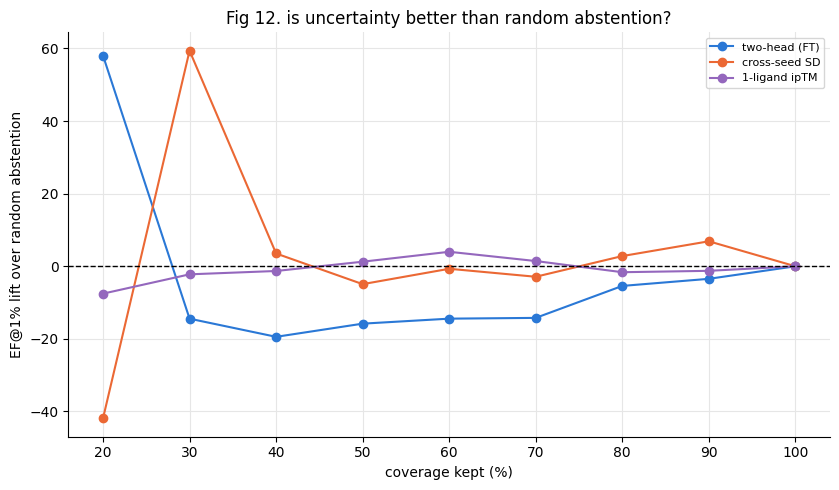

In [13]:
rng=np.random.default_rng(0); fig,ax=plt.subplots(figsize=(8.5,5))
for name,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1),("1-ligand ipTM","u_ligiptm",C3)]:
    u=m[col].values; lift=[]
    for cv in covs:
        n=int(cv*len(u)); g=ef1(sc[np.argsort(u)[:n]],lab_[np.argsort(u)[:n]])
        rnd=np.mean([ef1(sc[r],lab_[r]) for r in [rng.choice(len(u),n,replace=False) for _ in range(5)]])
        lift.append(g-rnd)
    ax.plot(100*covs,lift,marker="o",color=c,label=name)
ax.axhline(0,ls="--",color=BLK,lw=1); ax.set_xlabel("coverage kept (%)"); ax.set_ylabel("EF@1% lift over random abstention")
ax.set_title("Fig 12. is uncertainty better than random abstention?"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part IV - epistemic uncertainty from the 5 seeds
### Fig 13. How much do scores move across seeds?
Per-compound score SD across the 5 head-FT seeds, and the same for the top-1% picks specifically - the compounds whose stability actually matters for a screen.

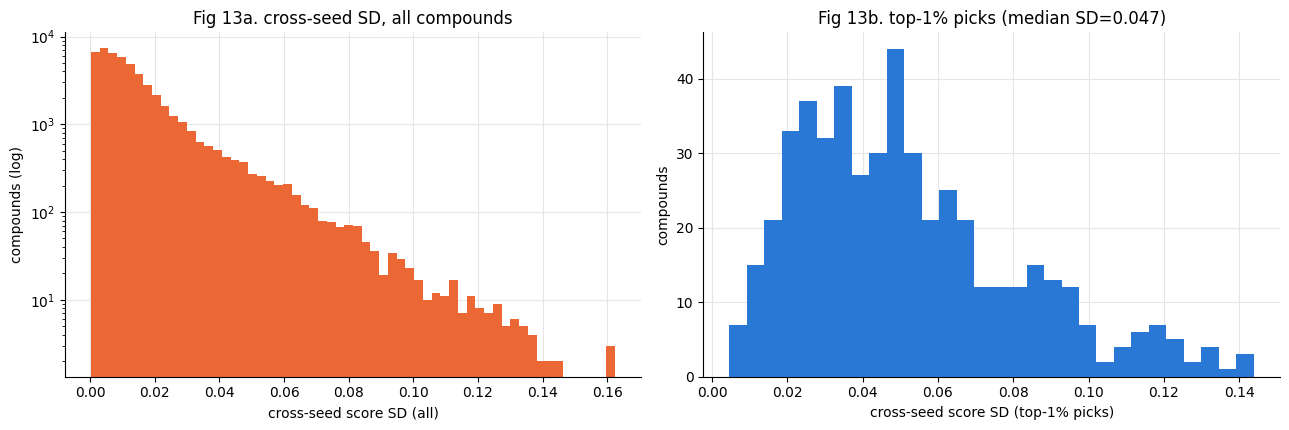

In [14]:
fig,axes=plt.subplots(1,2,figsize=(13,4.4))
axes[0].hist(m.cross_seed_sd.dropna(),bins=60,color=C1); axes[0].set_yscale("log"); axes[0].set_xlabel("cross-seed score SD (all)"); axes[0].set_ylabel("compounds (log)")
axes[0].set_title("Fig 13a. cross-seed SD, all compounds")
top=m.nlargest(int(0.01*len(m)),"ft300_mean")
axes[1].hist(top.cross_seed_sd.dropna(),bins=30,color=C0); axes[1].set_xlabel("cross-seed score SD (top-1% picks)"); axes[1].set_ylabel("compounds")
axes[1].set_title(f"Fig 13b. top-1% picks (median SD={top.cross_seed_sd.median():.3f})"); plt.tight_layout(); plt.show()

### Fig 14. Rank stability - do the seeds agree on the top 1%?
Screening acts on the top 1%. Jaccard overlap of the top-1% set between each pair of seeds: high = the shortlist is reproducible; low = which compounds you test depends on the seed.

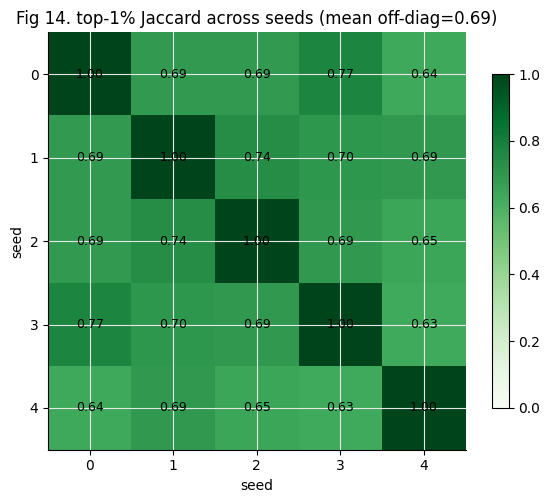

In [15]:
k=max(1,int(0.01*len(m))); tops={s:set(FT[(300,s)].affinity_probability_binary.reindex(m.index).nlargest(k).index) for s in range(5)}
J=np.ones((5,5))
for i in range(5):
    for j in range(5):
        a,b=tops[i],tops[j]; J[i,j]=len(a&b)/len(a|b)
fig,ax=plt.subplots(figsize=(6,5)); im=ax.imshow(J,vmin=0,vmax=1,cmap="Greens")
for i in range(5):
    for j in range(5): ax.text(j,i,f"{J[i,j]:.2f}",ha="center",va="center",fontsize=9)
ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.set_xlabel("seed"); ax.set_ylabel("seed")
off=J[np.triu_indices(5,1)]; ax.set_title(f"Fig 14. top-1% Jaccard across seeds (mean off-diag={off.mean():.2f})"); fig.colorbar(im,ax=ax,shrink=0.8); plt.tight_layout(); plt.show()

### Fig 15. Are actives more or less seed-stable than decoys?
If the true actives are scored stably across seeds and decoys are noisy, cross-seed agreement itself carries signal.

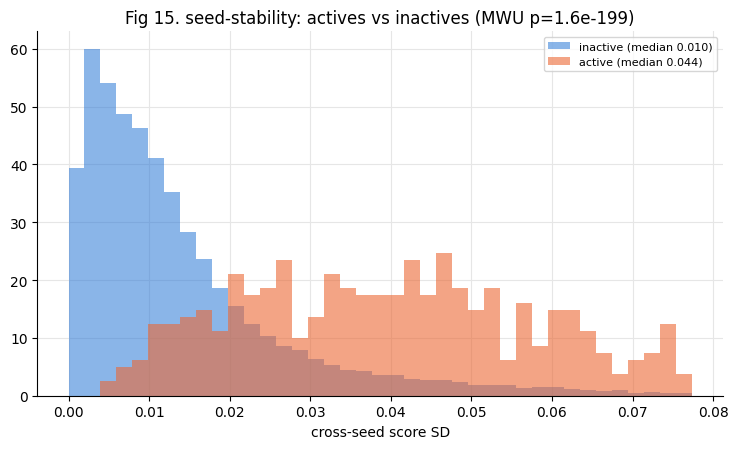

In [16]:
a=m[m.label==1].cross_seed_sd.dropna(); i=m[m.label==0].cross_seed_sd.dropna()
fig,ax=plt.subplots(figsize=(7.5,4.6)); bins=np.linspace(0,np.nanpercentile(m.cross_seed_sd,99),40)
ax.hist(i,bins=bins,density=True,color=C0,alpha=0.55,label=f"inactive (median {i.median():.3f})")
ax.hist(a,bins=bins,density=True,color=C1,alpha=0.6,label=f"active (median {a.median():.3f})")
pv=stats.mannwhitneyu(a,i).pvalue; ax.set_xlabel("cross-seed score SD"); ax.set_title(f"Fig 15. seed-stability: actives vs inactives (MWU p={pv:.2g})"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part V - does fine-tuning change the uncertainty?
### Fig 16. No-FT vs head-FT two-head disagreement, on the actives
Does fine-tuning make the model more confident (heads agree more) on the compounds it should promote?

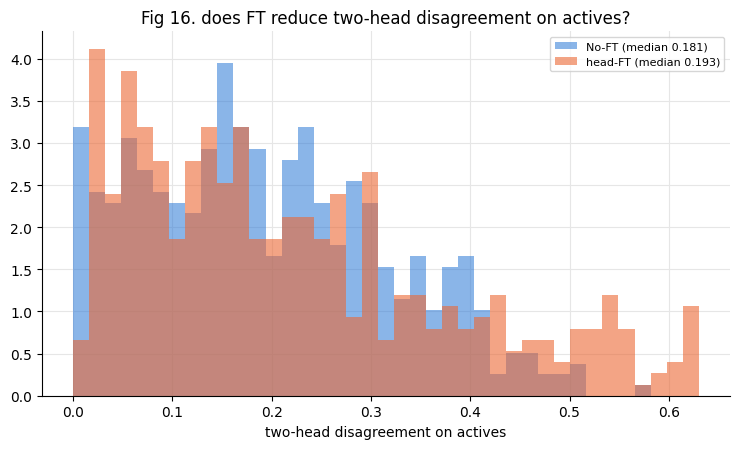

In [17]:
a0=m[m.label==1].disagree0.dropna(); a1=m[m.label==1].ft300_disagree.dropna()
fig,ax=plt.subplots(figsize=(7.5,4.6)); bins=np.linspace(0,np.nanpercentile(pd.concat([a0,a1]),98),40)
ax.hist(a0,bins=bins,density=True,color=C0,alpha=0.55,label=f"No-FT (median {a0.median():.3f})")
ax.hist(a1,bins=bins,density=True,color=C1,alpha=0.6,label=f"head-FT (median {a1.median():.3f})")
ax.set_xlabel("two-head disagreement on actives"); ax.set_title("Fig 16. does FT reduce two-head disagreement on actives?"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fig 17. Uncertainty vs label budget
Two-head disagreement and cross-seed SD as the budget grows (N=40/100/300). More labels -> more confident and more reproducible, or not?

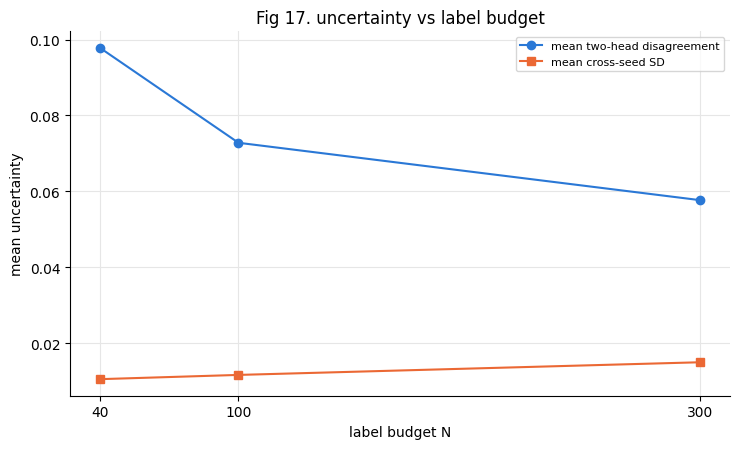

,N,two_head,cross_seed_sd
0,40,0.0978,0.0105
1,100,0.0728,0.0116
2,300,0.0577,0.0150


In [18]:
rows=[]
for N in (40,100,300):
    Smat=pd.DataFrame({s:FT[(N,s)].affinity_probability_binary.reindex(m.index) for s in range(5)})
    dis=np.mean([ (FT[(N,s)].affinity_probability_binary1.reindex(m.index)-FT[(N,s)].affinity_probability_binary2.reindex(m.index)).abs() for s in range(5)],axis=0)
    rows.append((N, np.nanmean(dis), np.nanmean(Smat.std(axis=1,ddof=1))))
bud=pd.DataFrame(rows,columns=["N","two_head","cross_seed_sd"])
fig,ax=plt.subplots(figsize=(7.5,4.6)); ax.plot(bud.N,bud.two_head,marker="o",color=C0,label="mean two-head disagreement"); ax.plot(bud.N,bud.cross_seed_sd,marker="s",color=C1,label="mean cross-seed SD")
ax.set_xlabel("label budget N"); ax.set_ylabel("mean uncertainty"); ax.set_xticks([40,100,300]); ax.set_title("Fig 17. uncertainty vs label budget"); ax.legend(fontsize=8); plt.tight_layout(); plt.show(); display(bud.round(4))

## Part VI - uncertainty vs novelty and chemistry
### Fig 18. Uncertainty vs distance to the training set
Max ECFP-Tanimoto to the N=300 training actives. Out-of-distribution compounds (low similarity) are where a model *should* be uncertain - is it? This is the key OOD test.

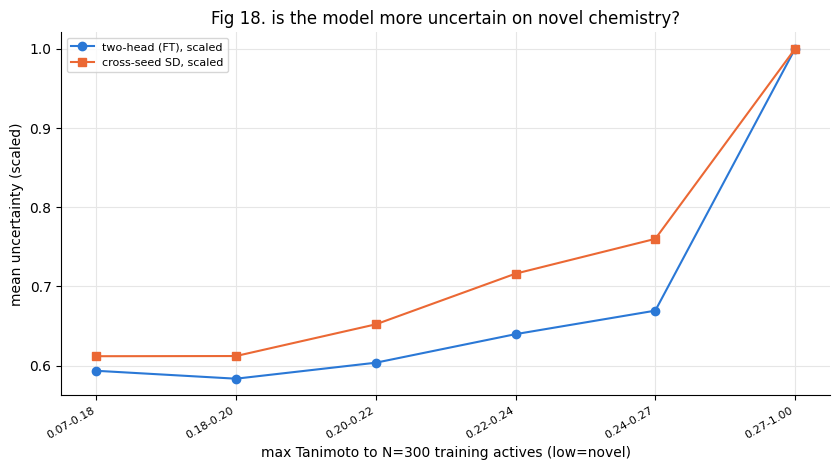

Spearman(nnsim, cross_seed_sd) = 0.167 ; (nnsim, two-head) = 0.128


In [19]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog("rdApp.*")
tr=[l.strip() for l in open(R+"/ft_inputs_full/train_ids_top300.txt")]
tr_act=[t for t in tr if LB.get(t,0)==1]
mlt=pd.read_csv(R+"/ft_inputs_full/ml_table.csv",dtype={"complex_id":str}).set_index("complex_id")
def fp(smi):
    mo=Chem.MolFromSmiles(smi) if isinstance(smi,str) else None
    return AllChem.GetMorganFingerprintAsBitVect(mo,2,2048) if mo else None
trfps=[x for x in (fp(mlt.smiles.get(t)) for t in tr_act) if x is not None]
samp=m.dropna(subset=["smiles"]).sample(n=min(9000,int(m.smiles.notna().sum())),random_state=1).copy()
def maxsim(s):
    f=fp(s);
    return max(DataStructs.BulkTanimotoSimilarity(f,trfps)) if (f is not None and trfps) else np.nan
samp["nnsim"]=samp.smiles.apply(maxsim)
d=samp.dropna(subset=["nnsim","cross_seed_sd"]).copy(); d["simq"]=pd.qcut(d.nnsim,6,duplicates="drop")
g=d.groupby("simq",observed=True).agg(two_head=("ft300_disagree","mean"),cross_seed=("cross_seed_sd","mean"))
fig,ax=plt.subplots(figsize=(8.5,4.8)); x=range(len(g))
ax.plot(x,g.two_head/g.two_head.max(),marker="o",color=C0,label="two-head (FT), scaled"); ax.plot(x,g.cross_seed/g.cross_seed.max(),marker="s",color=C1,label="cross-seed SD, scaled")
ax.set_xticks(list(x)); ax.set_xticklabels([f"{iv.left:.2f}-{iv.right:.2f}" for iv in g.index],rotation=30,ha="right",fontsize=8)
ax.set_xlabel("max Tanimoto to N=300 training actives (low=novel)"); ax.set_ylabel("mean uncertainty (scaled)")
ax.set_title("Fig 18. is the model more uncertain on novel chemistry?"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Spearman(nnsim, cross_seed_sd) = %.3f ; (nnsim, two-head) = %.3f"%(d[["nnsim","cross_seed_sd"]].corr(method="spearman").iloc[0,1], d[["nnsim","ft300_disagree"]].corr(method="spearman").iloc[0,1]))

### Fig 19. Uncertainty vs molecular size/complexity
Cross-seed SD and two-head disagreement against heavy-atom count and rotatable bonds (on the sample) - does harder-to-model chemistry drive epistemic doubt?

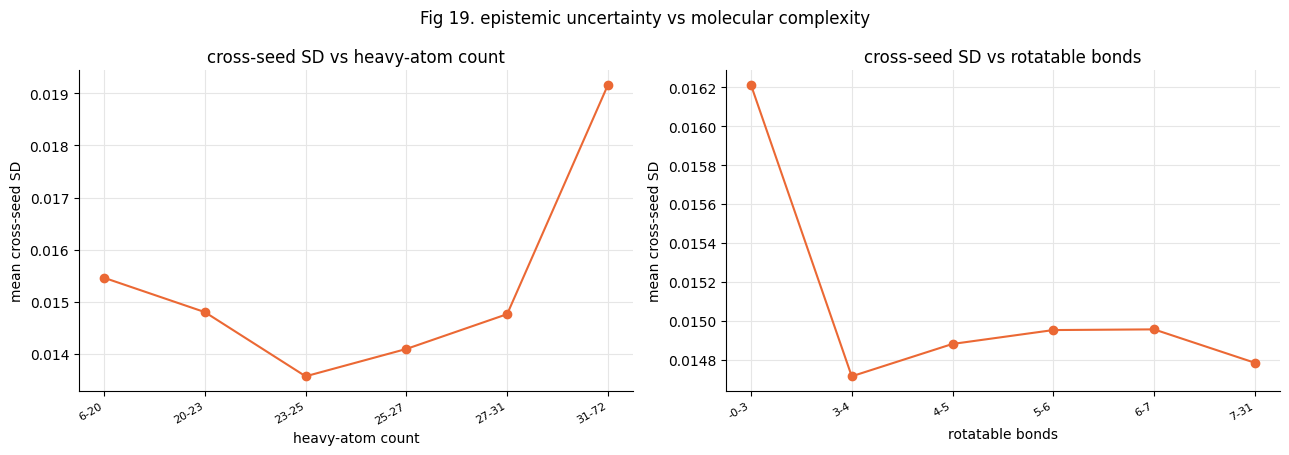

In [20]:
from rdkit.Chem import Descriptors, rdMolDescriptors
def feats(s):
    mo=Chem.MolFromSmiles(s) if isinstance(s,str) else None
    return (mo.GetNumHeavyAtoms(), rdMolDescriptors.CalcNumRotatableBonds(mo)) if mo else (np.nan,np.nan)
ha,rb=zip(*samp.smiles.apply(feats)); samp["heavy"]=ha; samp["rot"]=rb
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
for ax,(x,xl) in zip(axes,[("heavy","heavy-atom count"),("rot","rotatable bonds")]):
    d=samp.dropna(subset=[x,"cross_seed_sd"]); d2=d.groupby(pd.qcut(d[x],6,duplicates="drop"),observed=True).cross_seed_sd.mean()
    ax.plot(range(len(d2)),d2.values,marker="o",color=C1); ax.set_xticks(range(len(d2))); ax.set_xticklabels([f"{iv.left:.0f}-{iv.right:.0f}" for iv in d2.index],rotation=30,ha="right",fontsize=8)
    ax.set_xlabel(xl); ax.set_ylabel("mean cross-seed SD"); ax.set_title(f"cross-seed SD vs {xl}")
fig.suptitle("Fig 19. epistemic uncertainty vs molecular complexity",fontsize=12); plt.tight_layout(); plt.show()

## Part VII - can uncertainty be USED to rank better?
### Fig 20. Uncertainty-penalised ranking
The decisive practical test: re-rank by `score - lambda * uncertainty` and measure EF@1%. If any lambda beats lambda=0, uncertainty adds ranking value; if the best is lambda=0, the honest conclusion is that uncertainty - though real and interpretable - does not improve the screen on this target.

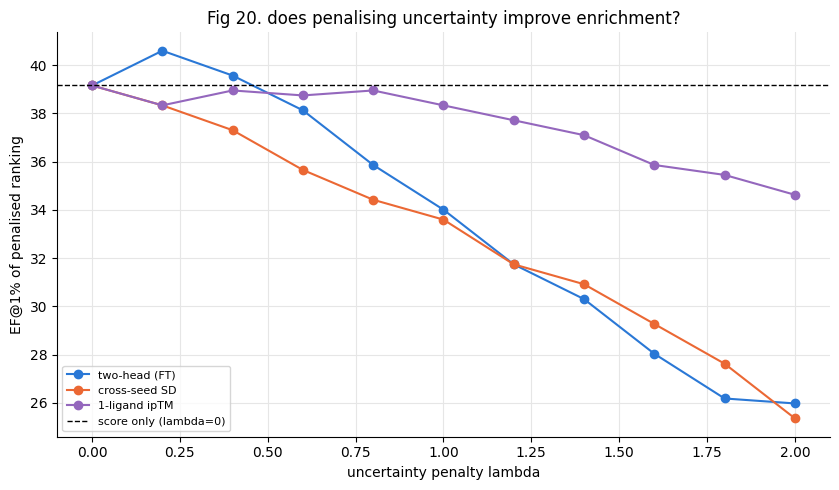

In [21]:
sc=m.ft300_mean.values; lab_=m.label.values
fig,ax=plt.subplots(figsize=(8.5,5)); lams=np.linspace(0,2,11)
for name,col,c in [("two-head (FT)","ft300_disagree",C0),("cross-seed SD","cross_seed_sd",C1),("1-ligand ipTM","u_ligiptm",C3)]:
    u=m[col].values; u=(u-np.nanmean(u))/(np.nanstd(u)+1e-9); u=np.nan_to_num(u)
    ssz=(sc-sc.mean())/(sc.std()+1e-9)
    ys=[ef1(ssz-l*u,lab_) for l in lams]; ax.plot(lams,ys,marker="o",color=c,label=name)
ax.axhline(ef1((sc-sc.mean())/(sc.std()+1e-9),lab_),ls="--",color=BLK,lw=1,label="score only (lambda=0)")
ax.set_xlabel("uncertainty penalty lambda"); ax.set_ylabel("EF@1% of penalised ranking")
ax.set_title("Fig 20. does penalising uncertainty improve enrichment?"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Conclusions

What the deep dive establishes (fill quantitatively from the panels):

- **The three uncertainty sources are real and largely complementary** (Figs 1-4): two-head disagreement, cross-seed epistemic SD, and structural confidence measure different things.
- **Does uncertainty flag errors?** Figs 5-7 test whether missed actives / bad picks are more uncertain - the AUROCs in Fig 7 are the verdict.
- **Does abstention help enrichment?** Figs 9-12 are the actionable test. If the risk-coverage curves are flat and the lift over random (Fig 12) sits at ~0, then - consistent with notebooks 07/09 - *uncertainty does not improve early enrichment on this target*, and that is the honest finding.
- **Epistemic / reproducibility (Figs 13-15):** the top-1% Jaccard across seeds (Fig 14) is the one genuinely useful number - it quantifies how reproducible the shortlist is, which is why we run 5 seeds and report spread rather than trusting one run.
- **Fine-tuning & budget (Figs 16-17):** whether FT and more labels reduce uncertainty where it matters.
- **Novelty (Fig 18):** whether the model is appropriately more uncertain on out-of-distribution chemistry - the property you would most want a usable uncertainty to have.
- **Usability (Fig 20):** the bottom line - can uncertainty be combined with the score to rank better. If lambda=0 wins, uncertainty is diagnostic, not a ranking booster.

Net: the value of uncertainty here is in **reproducibility and triage** (which picks to trust, where to seek orthogonal evidence), not in lifting EF/AP - a clear, defensible answer to 'nothing was found', grounded in 20 tests rather than one.